In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import random
from tqdm import tqdm

from src.experiment1_utils import *

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
reset_seeds()

In [4]:
# Data Parameters
dimension = 32
context_length = 8
N = 8192
stationary_noise_variance = 1e-2

In [5]:
synthetic_data, _, _ = generate_random_data(dimension, context_length, N, stationary_noise_variance)

In [6]:
train_data = synthetic_data[:7192]
test_data = synthetic_data[7192:]

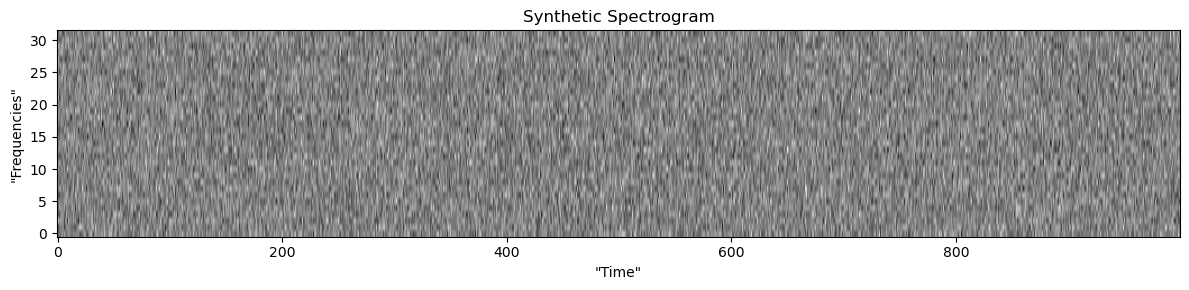

In [7]:
visualize_spectrogram(test_data)

In [8]:
X_train,Y_train = prepare_data(train_data, context_length)
coefficient_matrices_estimates = estimate_coefficients(X_train, Y_train, context_length)

In [9]:
# Getting A_i estimates based on the training data
noise_covariance_estimate_train, train_data_estimate = estimate_noise_covariance_and_data(train_data, coefficient_matrices_estimates, context_length)

In [10]:
# Seeing how the estimates predict the test data
noise_covariance_estimate_test, test_data_estimate = estimate_noise_covariance_and_data(test_data, coefficient_matrices_estimates, context_length)

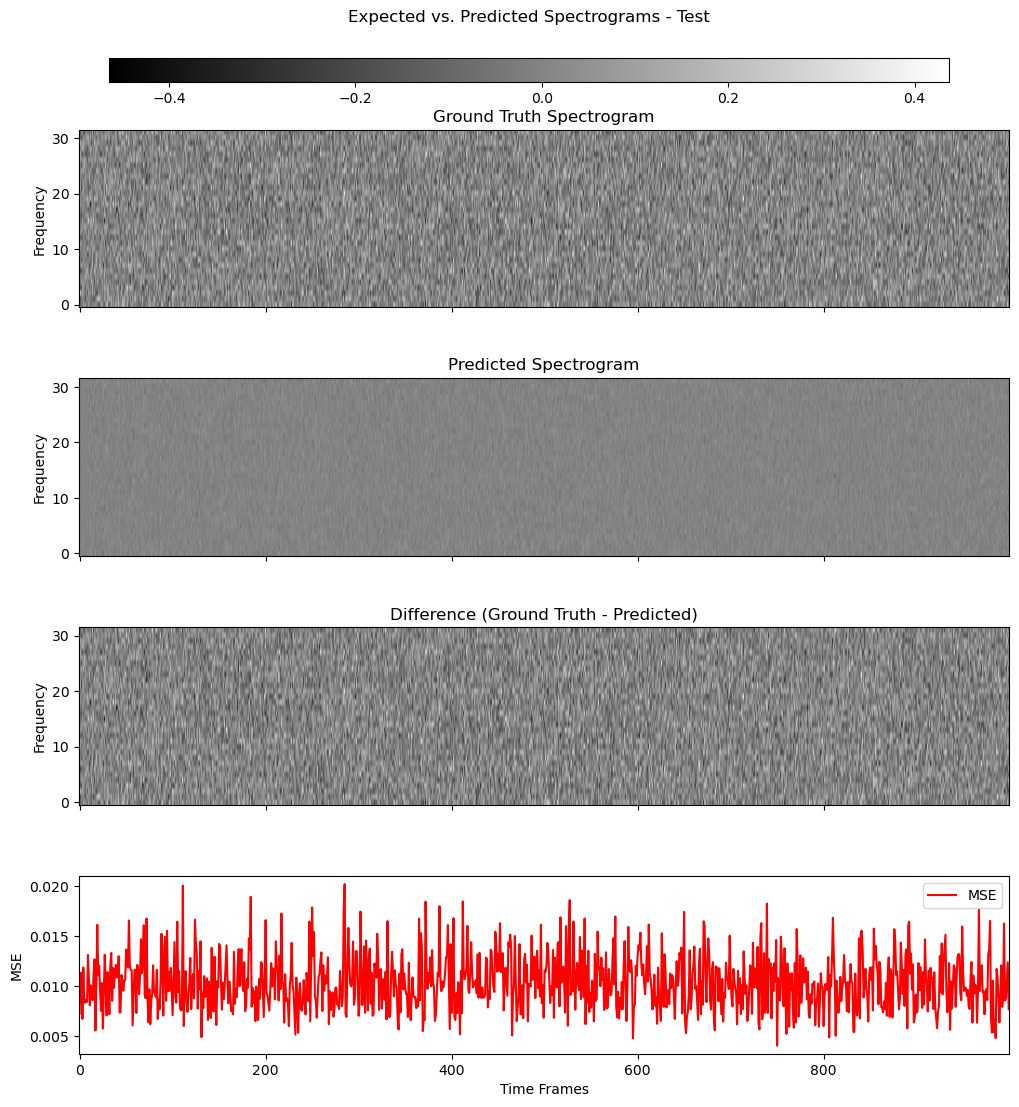

In [11]:
# Visualizing the predicted spectrograms on unseen data
visualize_MSE(test_data, test_data_estimate, "Expected vs. Predicted Spectrograms - Test")

In [12]:
# Dataset size sweep experiments to monitor parameter estimation MSE and the estimated entropy

# experiment parameters
# Data Parameters
dimension = 32
context_length = 8
stationary_noise_variance = 1


In [13]:
# data to be collected
train_MSE = []
train_entropy = []

test_MSE = []
test_entropy = []

coefficient_matrices_MSE_train = []
coefficient_matrices_MSE_test = []

In [14]:
# one quick run to get the ground truth parameters
reset_seeds()
_, gt_coefficient_matrices, gt_covariance_matrix = generate_random_data(dimension, context_length, 100, stationary_noise_variance)
gt_entropy = gauss_entropy(gt_covariance_matrix, dimension)
coefficient_matrix = list_to_multidimensional_matrix(gt_coefficient_matrices)

# Dataset size sweep
dataset_sizes = list(range( int(2e2), int(1e4)+1, int(2e2)))
for dataset_size in tqdm(dataset_sizes):
    reset_seeds()

    # data generation and preparation
    cur_synthetic_data, _, _ = generate_random_data(dimension, context_length, dataset_size, stationary_noise_variance)
    #print(dataset_size, np.mean(cur_synthetic_data))
    train_size = int(dataset_size*0.8)
    cur_train_data = cur_synthetic_data[:train_size]
    cur_test_data = cur_synthetic_data[train_size:]
    X_train,Y_train = prepare_data(cur_train_data, context_length)
    
    # estimating coefficients
    coefficient_matrices_estimates = estimate_coefficients(X_train, Y_train, context_length)

    noise_covariance_estimate_train, train_data_estimate = estimate_noise_covariance_and_data(cur_train_data, coefficient_matrices_estimates, context_length)
    noise_covariance_estimate_test, test_data_estimate = estimate_noise_covariance_and_data(cur_test_data, coefficient_matrices_estimates, context_length)

    train_MSE.append(MSE(cur_train_data, train_data_estimate))
    test_MSE.append(MSE(cur_test_data, test_data_estimate))

    train_entropy.append(gauss_entropy(noise_covariance_estimate_train, dimension))
    test_entropy.append(gauss_entropy(noise_covariance_estimate_test, dimension))

    #print(dataset_size, np.linalg.det(noise_covariance_estimate_train))
    coefficient_matrices_estimates_train = list_to_multidimensional_matrix(coefficient_matrices_estimates)
    #coefficient_matrices_estimates_test = utils.list_to_multidimensional_matrix(coefficient_matrices_estimates_test)

    coefficient_matrices_MSE_train.append(MSE(coefficient_matrix, coefficient_matrices_estimates))

  4%|▍         | 2/50 [00:00<00:03, 15.90it/s]

100%|██████████| 50/50 [00:41<00:00,  1.22it/s]


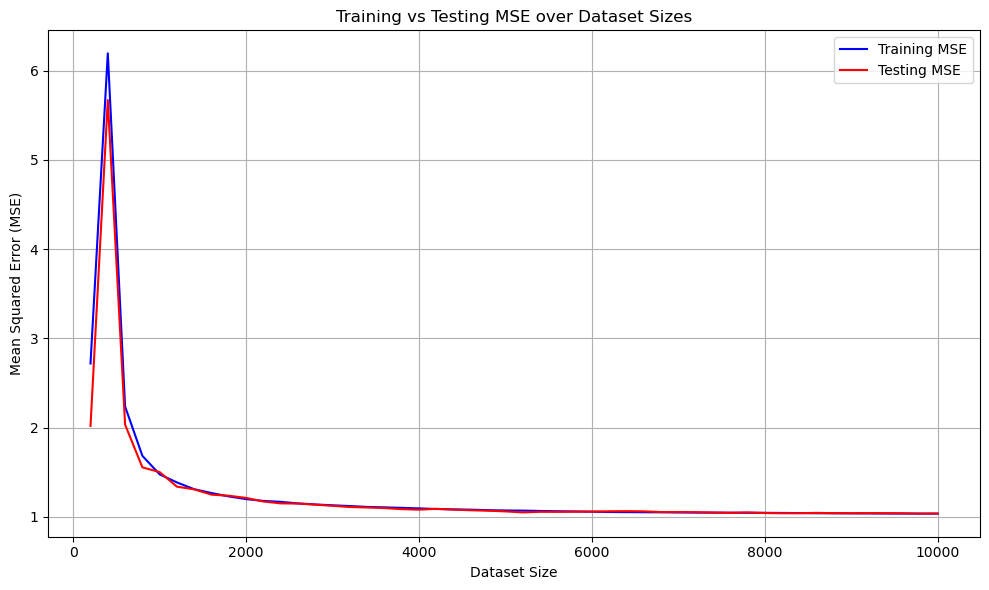

In [15]:
plot_MSE(dataset_sizes, train_MSE, test_MSE)

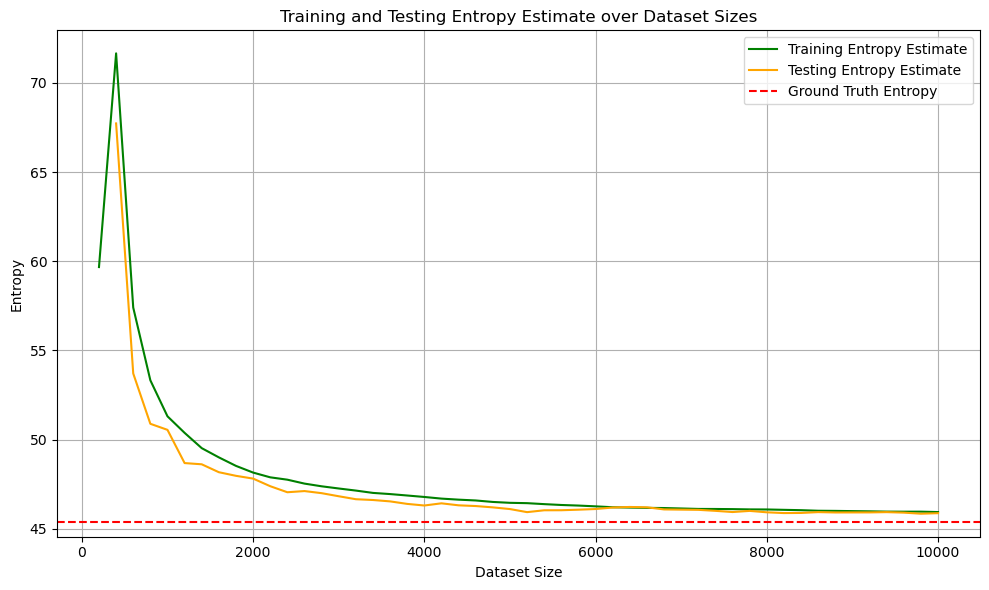

In [16]:
plot_entropy(dataset_sizes, train_entropy, test_entropy, gt_entropy)

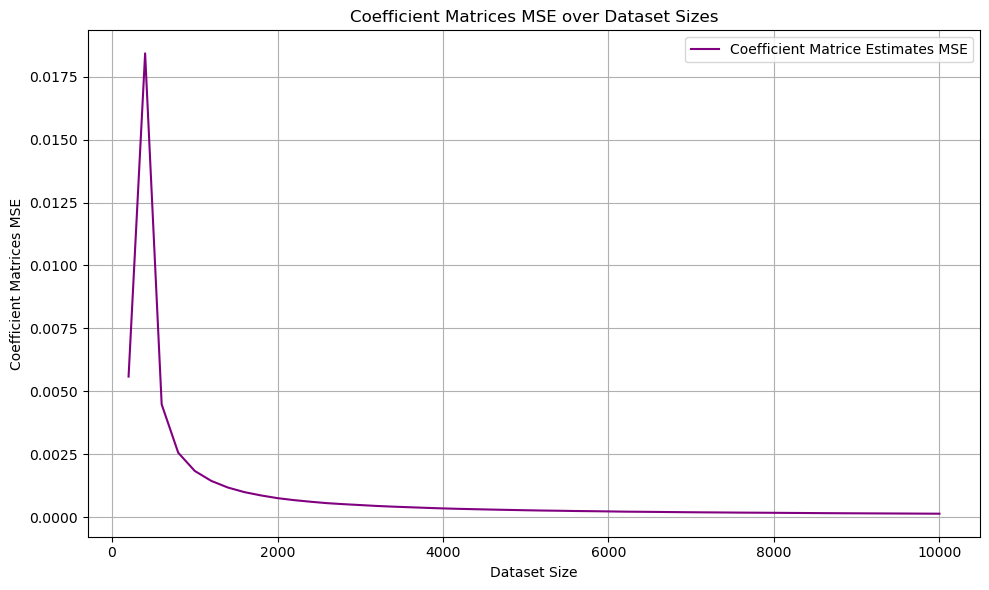

In [17]:
plot_coefficient_matrices_MSE(dataset_sizes, coefficient_matrices_MSE_train)

In [18]:
stationary_noise_variances = range(1, 101)
dimension = 32
dataset_size = int(1e6)
context_size = 8

noise_vs_entropy = np.zeros( ( len(list(stationary_noise_variances)) , 2 ) )
noise_vs_DEC = np.zeros( ( len(list(stationary_noise_variances)) , 2 ) )
noise_vs_upper_bound = np.zeros( ( len(list(stationary_noise_variances)) , 2 ) )

In [19]:
low, mid, up = analyze_noise_entropy(stationary_noise_variances, dimension, dataset_size, context_size, fix_random_seed=False)

Processing 100 noise variances with -4 jobs...


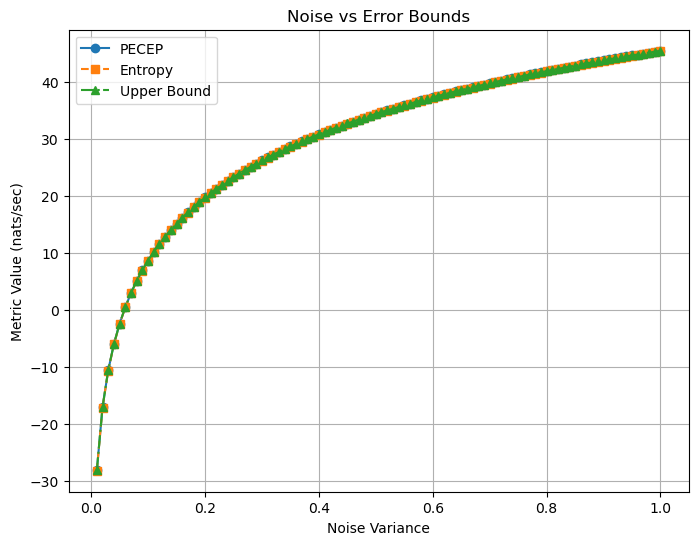

In [20]:
error_bounds(mid, low, up)

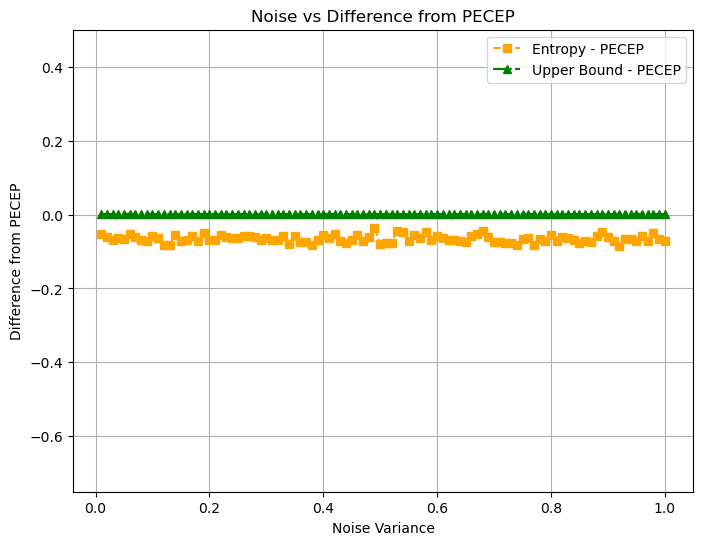

In [21]:
error_differences(mid, low, up)

In [22]:
stationary_noise_variances = range(1, 101)
dimension = 32
dataset_size = int(5e6)
context_size = 8

noise_vs_entropy = np.zeros( ( len(list(stationary_noise_variances)) , 2 ) )
noise_vs_DEC = np.zeros( ( len(list(stationary_noise_variances)) , 2 ) )
noise_vs_upper_bound = np.zeros( ( len(list(stationary_noise_variances)) , 2 ) )

In [23]:
low, mid, up = analyze_noise_entropy(stationary_noise_variances, dimension, dataset_size, context_size, fix_random_seed=False)

Processing 100 noise variances with -4 jobs...


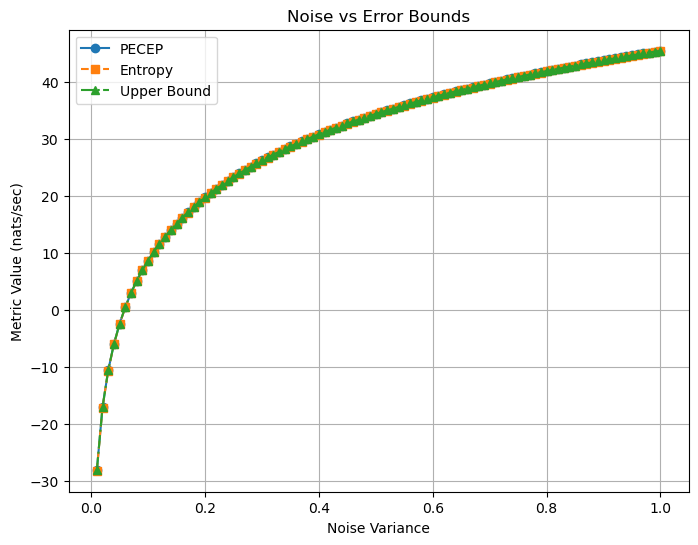

In [24]:
error_bounds(mid, low, up)

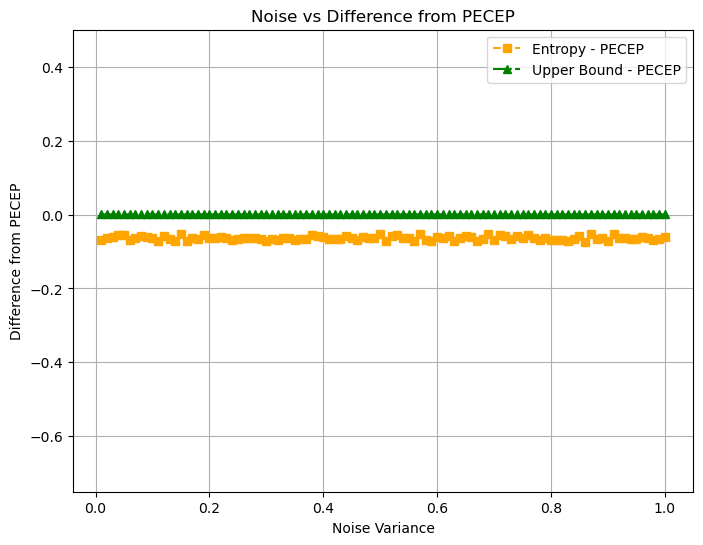

In [25]:
error_differences(mid, low, up)